## __IMPORT LIBRARIES__ ##

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy.optimize import brentq, minimize_scalar
from scipy.interpolate import CubicSpline

import cirq
import openfermion as of
import openfermionpyscf as ofpyscf

from qiskit import transpile, QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import StatevectorEstimator

from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel, depolarizing_error

from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SLSQP, COBYLA, SPSA

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

import warnings
warnings.filterwarnings("ignore")

## __MENCARI FUNGSI POTENSIAL DENGAN VQE__ ##

### __1. Inisialisasi__ ###

In [ ]:
#membuat list untuk 17 panjang ikatan untuk moelkul hidrogen
bond_lengths = np.array([
    #repulsive region
    0.5, 0.6, 0.65, 0.7, 0.72, 0.74, 0.76, 0.78, 0.8, 0.85, 0.9, 0.95,
    #region dari thesis
    1.0, 1.2, 1.3, 1.39, 1.4, 1.4011, 1.41, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2])

#membuat array kosong untuk menyimpan energi ground state hasil simulasi pada panjang ikatan yg berbeda
energies_exact = []
energies_sv = []
energies_aer = []
energies_hw = []

### __2. VQE__ ###

In [3]:
results = []

for bond_length in bond_lengths:
    #update PySCFDriver dengan panjang ikatan dinamis
    driver = PySCFDriver(
        atom=f"H 0 0 0; H 0 0 {bond_length}",  # ← PERUBAHAN DI SINI
        unit=DistanceUnit.ANGSTROM,
        basis="sto3g",
    )
    problem        = driver.run()
    mapper         = ParityMapper(num_particles=problem.num_particles)
    qubit_op       = mapper.map(problem.hamiltonian.second_q_op())
    num_particles  = problem.num_particles
    num_spatial    = problem.num_spatial_orbitals

    nuclear_rep = problem.hamiltonian.nuclear_repulsion_energy

    #referensi exact
    ref_result = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
    E_exact    = ref_result.eigenvalue.real + nuclear_rep

    #fungsi pembantu: buat ansatz UCCSD + HF init
    n_qubits = qubit_op.num_qubits
    def build_ansatz():
        hf = HartreeFock(
            num_spatial_orbitals = problem.num_spatial_orbitals,
            num_particles        = problem.num_particles,
            qubit_mapper         = mapper,
        )
        return UCCSD(
            num_spatial_orbitals = problem.num_spatial_orbitals,
            num_particles        = problem.num_particles,
            qubit_mapper         = mapper,
            initial_state        = hf,
        )
    
    #optimizer 
    def make_callback(history):
        def cb(eval_count, params, energy, std):
            history.append(energy)
            #print(f"  iter {eval_count:3d} | E = {energy:.6f} Ha")
        return cb
    
    #memakai statevctor untuk warming starting point
    ansatz_sv   = build_ansatz()
    history_sv  = []
 
    vqe_sv = VQE(
        estimator    = StatevectorEstimator(),
        ansatz       = ansatz_sv,
        optimizer    = SLSQP(maxiter=300),
        initial_point= np.zeros(ansatz_sv.num_parameters),
        callback     = make_callback(history_sv),
    )
    result_sv = vqe_sv.compute_minimum_eigenvalue(qubit_op)

    #VQE dengan aer simulator + noise model
    noise_model  = NoiseModel()
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(0.001, 1), ["u1", "u2", "u3", "rz", "sx", "x"]
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(0.005, 2), ["cx","ecr"]
    )
    #transpalasi
    fake_backend = GenericBackendV2(num_qubits=4, seed=42)
    #backend = AerSimulator(noise_model=noise_model)
    pm = generate_preset_pass_manager(
        optimization_level=3,
        backend=fake_backend
    )
    ansatz_aer   = build_ansatz()
    ansatz_aer_t = pm.run(ansatz_aer)
    qubit_op_t    = qubit_op.apply_layout(ansatz_aer_t.layout)

    noisy_estimator = AerEstimator(
        options={"backend_options": {"noise_model": noise_model}, 
                "run_options": {"shots": 32768}
            }
    )
    history_aer = []
    optimal_theta = result_sv.optimal_point
    vqe_aer = VQE(
        estimator    = noisy_estimator,
        ansatz       = ansatz_aer_t,
        optimizer    = COBYLA(maxiter=500),
        initial_point= optimal_theta,  #pakai hasil statevector sebagai titik awal
        callback     = make_callback(history_aer),
    )
    result_aer = vqe_aer.compute_minimum_eigenvalue(qubit_op)
    E_aer      = result_aer.eigenvalue.real + nuclear_rep
    results.append({
        'bond_length': bond_length,
        'E_exact': E_exact,
        'E_vqe': E_aer,
        'iterations': len(history_aer)
    })

### __3. Perubahan Energi Ground State setiap bond length__ ##

In [ ]:
import pandas as pd

df = pd.DataFrame(results)
print(df.to_string(index=False))

 bond_length   E_exact     E_vqe  iterations
      0.5000 -1.055160 -1.020089          33
      0.6000 -1.116286 -1.086449          34
      0.6500 -1.129905 -1.102316          33
      0.7000 -1.136189 -1.110625          35
      0.7200 -1.137112 -1.112298          33
      0.7400 -1.137284 -1.113189          34
      0.7600 -1.136796 -1.113390          34
      0.7800 -1.135727 -1.112982          35
      0.8000 -1.134148 -1.112035          35
      0.8500 -1.128362 -1.107719          34
      0.9000 -1.120560 -1.101242          35
      0.9500 -1.111339 -1.093216          36
      1.0000 -1.101150 -1.084108          36
      1.2000 -1.056741 -1.043077          38
      1.3000 -1.035186 -1.022742          34
      1.3900 -1.017339 -1.005769          36
      1.4000 -1.015468 -1.003983          36
      1.4011 -1.015264 -1.003788          34
      1.4100 -1.013622 -1.002220          35
      1.5000 -0.998149 -0.987398          41
      1.6000 -0.983473 -0.973261          34
      1.80

### __4. Plotting__ ###

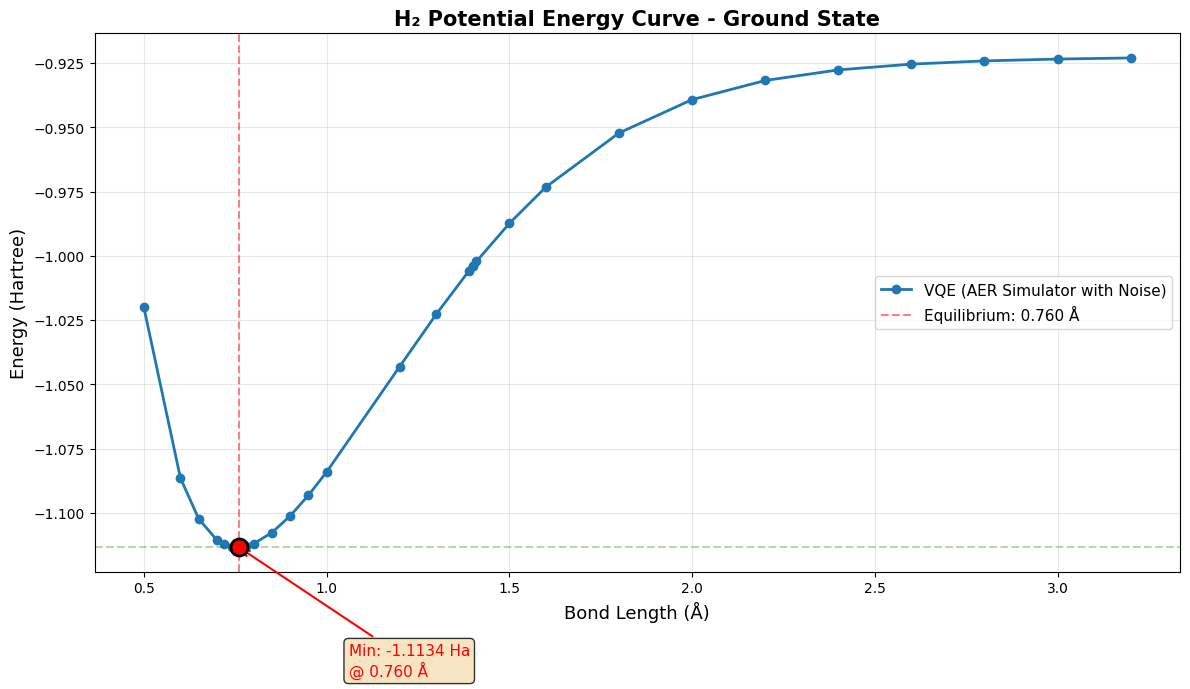


Equilibrium bond length: 0.7600 Å
Minimum energy (ground state): -1.113390 Ha


In [5]:
bond_lengths_plot = np.array([r['bond_length'] for r in results])
energies = np.array([r['E_vqe'] for r in results])

r = bond_lengths_plot
E = energies

min_idx = np.argmin(energies)
min_bond = bond_lengths_plot[min_idx]
min_energy = energies[min_idx]

plt.figure(figsize=(12, 7))
plt.plot(bond_lengths_plot, energies, 'o-', linewidth=2, 
         markersize=6, label='VQE (AER Simulator with Noise)')

# Mark minimum dengan garis vertikal dan horizontal
plt.axvline(min_bond, color='red', linestyle='--', alpha=0.5, 
            label=f'Equilibrium: {min_bond:.3f} Å')
plt.axhline(min_energy, color='green', linestyle='--', alpha=0.3)

# Annotate minimum point
plt.scatter([min_bond], [min_energy], color='red', s=150, 
            zorder=5, edgecolor='black', linewidth=2)
plt.annotate(f'Min: {min_energy:.4f} Ha\n@ {min_bond:.3f} Å',
             xy=(min_bond, min_energy),
             xytext=(min_bond + 0.3, min_energy - 0.05),
             fontsize=11, color='red',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.xlabel('Bond Length (Å)', fontsize=13)
plt.ylabel('Energy (Hartree)', fontsize=13)
plt.title('H₂ Potential Energy Curve - Ground State', fontsize=15, weight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Equilibrium bond length: {min_bond:.4f} Å")
print(f"Minimum energy (ground state): {min_energy:.6f} Ha")
print(f"{'='*50}")

### __5. Menemukan Fungsi Potensial dalam bentuk polinomial__ ###

  POLYNOMIAL FIT POTENTIAL

  V(x) = α(+1.000x -13.607x² +14.559x³ -4.615x⁴)

  di mana:
    x   = r - r_eq = r - 0.7563 Å  (displacement)
    α   = -0.058763 Hartree/Å

  Koefisien absolut:
    c1 = -0.058763 Ha/Å
    c2 = 0.799590 Ha/Å²
    c3 = -0.855544 Ha/Å³
    c4 = 0.271180 Ha/Å⁴

  R² = 0.99465824


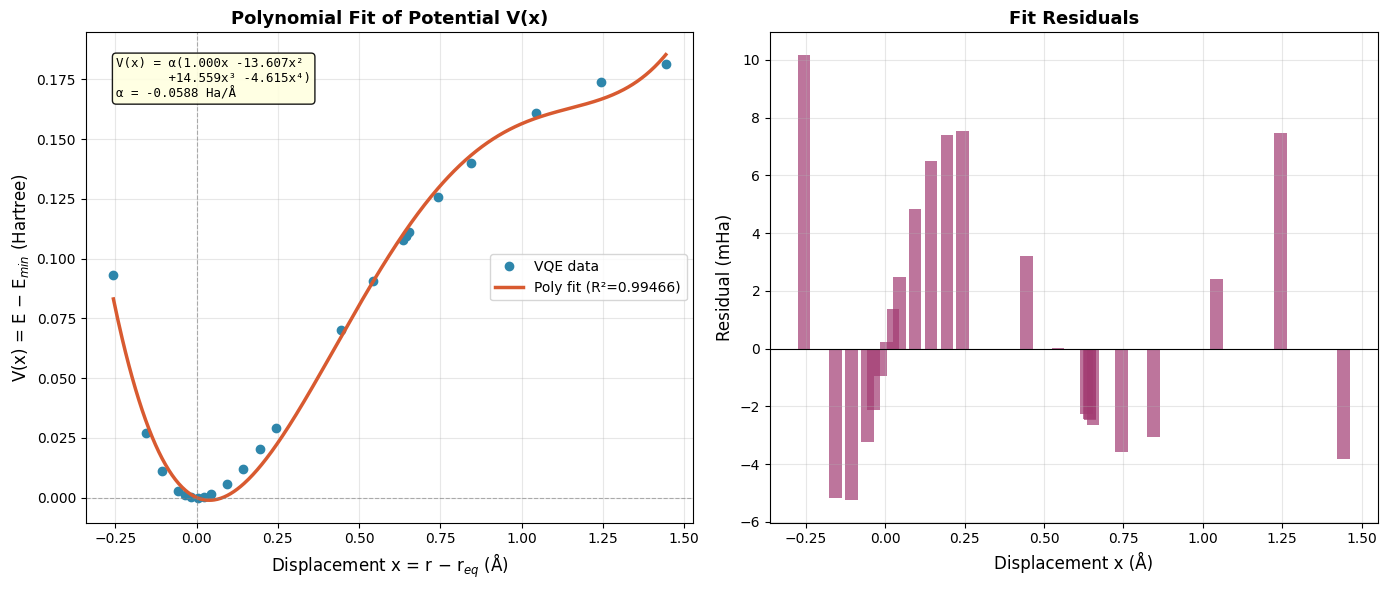

In [6]:
from numpy.polynomial import polynomial as P
from scipy.interpolate import CubicSpline

# ══════════════════════════════════════════════════════════════════════
# POLYNOMIAL FIT: V(x) = α(c1·x + c2·x² + c3·x³ + c4·x⁴)
# x = r - r_eq  (displacement dari equilibrium)
# ══════════════════════════════════════════════════════════════════════

# ── Gunakan data spline untuk kepadatan titik lebih tinggi ────────────
cs     = CubicSpline(r, E)
r_fine = np.linspace(r.min(), r.max(), 10000)
E_fine = cs(r_fine)
min_idx = np.argmin(E_fine)
r_eq    = r_fine[min_idx]
E_min   = E_fine[min_idx]

# ── Definisikan displacement x = r - r_eq ────────────────────────────
x_all  = r      - r_eq       # displacement dari data asli
x_fine = r_fine - r_eq       # displacement dari spline

# Geser energi supaya V(r_eq) = 0  → V(x) = E(x) - E_min
V_all  = E      - E_min
V_fine = E_fine - E_min

# ── Fit polynomial orde 4 (tanpa konstanta, karena V(0)=0) ────────────
# V(x) = c1·x + c2·x² + c3·x³ + c4·x⁴
# Gunakan np.polyfit dengan constraint: no constant term
# Caranya: fit orde 4 lalu paksa koefisien orde 0 = 0

# Pilih range fit yang wajar (sekitar ±1.5 Å dari equilibrium)
mask_fit = (r >= r_eq - 1.0) & (r <= r_eq + 1.5)
x_fit    = x_all[mask_fit]
V_fit    = V_all[mask_fit]

# Fit polynomial orde 4 tanpa intercept
# V(x) = a1*x + a2*x^2 + a3*x^3 + a4*x^4
A = np.column_stack([x_fit, x_fit**2, x_fit**3, x_fit**4])
coeffs, residuals, rank, sv = np.linalg.lstsq(A, V_fit, rcond=None)
c1, c2, c3, c4 = coeffs

# ── Normalisasi: faktor α = c1 (supaya koefisien x = 1, atau bisa alpha lain)
# Alternatif: α = nilai konstan, tampilkan koefisien relatif
alpha   = c1   # normalisasi terhadap koefisien linear
c1n     = c1 / alpha
c2n     = c2 / alpha
c3n     = c3 / alpha
c4n     = c4 / alpha

# ── Evaluasi fit ──────────────────────────────────────────────────────
V_pred = c1*x_fit + c2*x_fit**2 + c3*x_fit**3 + c4*x_fit**4
ss_res = np.sum((V_fit - V_pred)**2)
ss_tot = np.sum((V_fit - np.mean(V_fit))**2)
R2     = 1 - ss_res/ss_tot

# ── Print persamaan ───────────────────────────────────────────────────
print("=" * 60)
print("  POLYNOMIAL FIT POTENTIAL")
print("=" * 60)
print(f"\n  V(x) = α({c1n:+.3f}x {c2n:+.3f}x² {c3n:+.3f}x³ {c4n:+.3f}x⁴)")
print(f"\n  di mana:")
print(f"    x   = r - r_eq = r - {r_eq:.4f} Å  (displacement)")
print(f"    α   = {alpha:.6f} Hartree/Å")
print(f"\n  Koefisien absolut:")
print(f"    c1 = {c1:.6f} Ha/Å")
print(f"    c2 = {c2:.6f} Ha/Å²")
print(f"    c3 = {c3:.6f} Ha/Å³")
print(f"    c4 = {c4:.6f} Ha/Å⁴")
print(f"\n  R² = {R2:.8f}")
print("=" * 60)

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel kiri: V(x) vs x dengan polynomial fit
ax1 = axes[0]
x_plot  = np.linspace(x_fit.min(), x_fit.max(), 500)
V_poly  = c1*x_plot + c2*x_plot**2 + c3*x_plot**3 + c4*x_plot**4

ax1.plot(x_all[mask_fit], V_fit, 'o', color="#2E86AB", ms=6, label="VQE data")
ax1.plot(x_plot, V_poly, '-', color="#D85A30", lw=2.5,
         label=f"Poly fit (R²={R2:.5f})")
ax1.axvline(0, color="gray", ls="--", lw=0.8, alpha=0.6)
ax1.axhline(0, color="gray", ls="--", lw=0.8, alpha=0.6)

# Tampilkan persamaan di plot
eq_str = (f"V(x) = α({c1n:.3f}x {c2n:+.3f}x²\n"
          f"       {c3n:+.3f}x³ {c4n:+.3f}x⁴)\n"
          f"α = {alpha:.4f} Ha/Å")
ax1.text(0.05, 0.95, eq_str, transform=ax1.transAxes, fontsize=9,
         verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

ax1.set_xlabel("Displacement x = r − r$_{eq}$ (Å)", fontsize=12)
ax1.set_ylabel("V(x) = E − E$_{min}$ (Hartree)", fontsize=12)
ax1.set_title("Polynomial Fit of Potential V(x)", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Panel kanan: residual error
ax2 = axes[1]
V_pred_all = c1*x_fit + c2*x_fit**2 + c3*x_fit**3 + c4*x_fit**4
residual   = (V_fit - V_pred_all) * 1000   # konversi ke mHa

ax2.bar(x_fit, residual, width=0.04, color="#A23B72", alpha=0.7)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_xlabel("Displacement x (Å)", fontsize=12)
ax2.set_ylabel("Residual (mHa)", fontsize=12)
ax2.set_title("Fit Residuals", fontsize=13, fontweight="bold")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("vqe_polynomial_fit.png", dpi=150, bbox_inches="tight")
plt.show()

## __QUANTUM TUNNELING__ ##

### __1. Parameter__ ###

In [ ]:
#hasil dari vqe
r_eq = r_eq
E_min = E_min
alpha = alpha

#koefisien normalisasi dri operator potensial
c1n = c1n
c2n = c2n
c3n = c3n
c4n = c4n
#print(c1n, c2n, c3n, c4n)

#konstanta fisika
mu_au = 918.076  # reduced mass in atomic units (for H2)
hbar = 1.0     # Planck's constant in atomic units
au2fs = 0.02418884  # atomic unit of time in femtoseconds
au2eV = 27.2114  # atomic unit of energy in eV
cm2au = 4.556335e-6  # wavenumber (cm⁻¹) to atomic units

#grid parameter
N = 64
n_qubits = int(np.log2(N))
L = 2.5
dx = 2*L/N

#parameter trotter
dt_au = 1.0
n_steps = 3000
n_steps_qc = 50

print("=" * 65)
print("  H₂ TROTTER DYNAMICS & TUNNELING PROBABILITY")
print("=" * 65)
print(f"  r_eq    = {r_eq:.4f} Å")
print(f"  E_min   = {E_min:.6f} Ha")
print(f"  α       = {alpha:.6f} Ha/Å")
print(f"  Grid    : N={N} points, L=±{L} Å, dx={dx:.4f} Å")
print(f"  n_qubits: {n_qubits} (untuk QFT circuit)")
print(f"  Δt      : {dt_au} a.u. = {dt_au*au2fs:.4f} fs")
print(f"  Steps   : {n_steps} (split-op) | {n_steps_qc} (quantum circuit)")
print("=" * 65)

  H₂ TROTTER DYNAMICS & TUNNELING PROBABILITY
  r_eq    = 0.7563 Å
  E_min   = -1.113401 Ha
  α       = -0.058763 Ha/Å
  Grid    : N=64 points, L=±2.5 Å, dx=0.0781 Å
  n_qubits: 6 (untuk QFT circuit)
  Δt      : 1.0 a.u. = 0.0242 fs
  Steps   : 3000 (split-op) | 50 (quantum circuit)


### __2. Fungsi Potensial dari VQE__ ###

In [ ]:
def V_vqe(x):
    """
    Potensial dari polynomial fit VQE.
    V(x) = α(c1n·x + c2n·x² + c3n·x³ + c4n·x⁴)
    x dalam Å (displacement dari r_eq), return dalam Ha
    """
    return alpha * (c1n*x + c2n*x**2 + c3n*x**3 + c4n*x**4)

def dV_dx(x):
    """Turunan pertama V(x) — analitik dari polynomial"""
    return alpha * (c1n + 2*c2n*x + 3*c3n*x**2 + 4*c4n*x**3)

def d2V_dx2(x):
    """Turunan kedua V(x) — untuk frekuensi harmonik"""
    return alpha * (2*c2n + 6*c3n*x + 12*c4n*x**2)

### __3. Derivasi Parameter Secara Otomatis__ ###

    3.1 Minimum potensial

In [ ]:
from scipy.optimize import minimize_scalar

#mencari x_min: titik dimana dV/dx=0 dan d2V/dx2>0
result_min = minimize_scalar(V_vqe, bounds=(-2.0, 2.0), method='bounded')
x_min      = result_min.x
V_min      = result_min.fun

print(f"\n[1] MINIMUM POTENSIAL")
print(f"    x_min (numerik)  = {x_min:.6f} Å")
print(f"    V_min            = {V_min:.6f} Ha")
print(f"    ✓ Konsisten dengan x=0 (displacement dari r_eq): "
      f"{'YA' if abs(x_min) < 0.05 else f'TIDAK — x_min={x_min:.3f} Å'}")


[1] MINIMUM POTENSIAL
    x_min (numerik)  = 0.039167 Å
    V_min            = -0.001126 Ha
    ✓ Konsisten dengan x=0 (displacement dari r_eq): YA


    3.2 Karakter potensial: single-well atau double-well

In [ ]:
#terdapat barrier jika dV/dx = 0 dan d2V/dx2 < 0

r_min_data = bond_lengths.min()   # Å — bond length terpendek di data VQE
r_max_data = bond_lengths.max()   # Å — bond length terpanjang di data VQE

x_range_left  = r_min_data - r_eq    # displacement terkecil (negatif)
x_range_right = r_max_data - r_eq    # displacement terbesar (positif)

def find_critical_points(x_range=(-3.0, 3.0), n_scan=1000):
    x_scan  = np.linspace(*x_range, n_scan)
    dV_scan = dV_dx(x_scan)
    
    critical_points = []
    for i in range(len(x_scan) - 1):
        # Sign change → ada akar (titik kritis)
        if dV_scan[i] * dV_scan[i+1] < 0:
            try:
                x_crit = brentq(dV_dx, x_scan[i], x_scan[i+1])
                curv   = d2V_dx2(x_crit)
                jenis  = 'min' if curv > 0 else 'max'
                critical_points.append((x_crit, jenis, V_vqe(x_crit)))
            except:
                pass
    return critical_points

crits = find_critical_points()

minima  = [(x, V) for x, j, V in crits if j == 'min']
maxima  = [(x, V) for x, j, V in crits if j == 'max']

DOUBLE_WELL = len(minima) >= 2 and len(maxima) >= 1
if DOUBLE_WELL:
    print(f"    → DOUBLE-WELL ✓ (tunneling antar sumur tersedia)")
else:
    print(f"    → SINGLE-WELL (tunneling = menembus turning point klasik)")

    → SINGLE-WELL (tunneling = menembus turning point klasik)


    3.3 Frekuensi harmonik dari kurvatur minimum

In [ ]:
# ω = √(d²V/dx² / μ)  pada x = x_min
# Dari Hooke's law: V(x) ≈ ½ k x²  →  k = d²V/dx²  →  ω = √(k/μ)

k_force = d2V_dx2(x_min)           # Ha/Å² — konstanta gaya harmonik
omega   = np.sqrt(k_force / mu_au) # a.u.⁻¹ — frekuensi angular
nu_cm1  = omega / (2*np.pi * cm2au)# cm⁻¹ — bilangan gelombang vibrasi
E_ZPE   = 0.5 * hbar * omega       # Ha — zero-point energy

# Amplitudo klasik pada energi ZPE:
# E_ZPE = ½ k A²  →  A = √(2 E_ZPE / k)
A_classical = np.sqrt(2 * E_ZPE / k_force)  # Å
print(f"A_klasik (ZPE)    = {A_classical:.4f} Å  (amplitudo vibrasi)")

A_klasik (ZPE)    = 0.1669 Å  (amplitudo vibrasi)


    3.4 Turning point klasik

In [ ]:
#Turning point: V(x_tp) = E_total (partikel berbalik arah)
#Untuk partikel pada E_ZPE: V(x_tp) = E_ZPE

def find_turning_points(E_total, x_min_local, x_range=3.0):
    # Geser potensial supaya V(x_min) = 0
    V_shifted = lambda x: V_vqe(x) - V_min - E_total

    #Turning point kiri
    try:
        x_tp_left  = brentq(V_shifted, x_min_local - x_range, x_min_local - 1e-6)
    except:
        x_tp_left  = x_min_local - x_range
    
    #Turning point kanan
    try:
        x_tp_right = brentq(V_shifted, x_min_local + 1e-6, x_min_local + x_range)
    except:
        x_tp_right = x_min_local + x_range
    
    return x_tp_left, x_tp_right

x_tp_left_zpe, x_tp_right_zpe = find_turning_points(E_ZPE, x_min)

print(f"\n[4] TURNING POINT KLASIK (pada E = E_ZPE)")
print(f"    x_tp_left  = {x_tp_left_zpe:.4f} Å")
print(f"    x_tp_right = {x_tp_right_zpe:.4f} Å")
print(f"    Lebar klasik = {x_tp_right_zpe - x_tp_left_zpe:.4f} Å")
print(f"    Partikel di LUAR range ini = TUNNELING KUANTUM")


[4] TURNING POINT KLASIK (pada E = E_ZPE)
    x_tp_left  = -0.1141 Å
    x_tp_right = 0.2262 Å
    Lebar klasik = 0.3402 Å
    Partikel di LUAR range ini = TUNNELING KUANTUM


### __4. AUTO DERIVE PARAMETER SIMULASI__ ###

In [ ]:
print(f"\n[5] AUTO-DERIVASI PARAMETER SIMULASI")
if DOUBLE_WELL:
    #posisi susmur kiri
    x_min_left = min(minima, key=lambda m: m[0])[0]
    x_min_right = max(minima, key=lambda m: m[0])[0]

    #puncak barrier
    x_bar = maxima[0][0]
    V_bar = maxima[0][1]

    #x0 dimulai di dasar sumur kiri, x0 = x0 = argmin V(x) untuk x < x_barrier
    x0 = x_min_left

    #x_barrier: puncak barrier
    x_barrier = x_bar
    V_barrier = V_bar

    #k0, syarat dari tunneling: E_kin = f_tunnel x V_barrier
    #f_tunnel dipilih supaya ada tunneling tapi tidak terlalu kecil:
    #WKB menunjukkan tunneling signifikan saat E_kin > ~10% V_barrier
    f_tunnel = 0.10                              # 10% dari barrier
    k0       = np.sqrt(2 * mu_au * f_tunnel * V_barrier)
    E_kin    = k0**2 / (2 * mu_au)

    print(f"    Mode          : DOUBLE-WELL")
    print(f"    x_min_left    = {x_min_left:.4f} Å")
    print(f"    x_min_right   = {x_min_right:.4f} Å")
    print(f"    x_barrier     = {x_barrier:.4f} Å  (puncak barrier)")
    print(f"    V_barrier     = {V_barrier:.6f} Ha = {V_barrier*au2eV:.4f} eV")

else:
    #single well → tunneling ke luar turning point klasik
    x0 = x_min + A_classical/2
    x_barrier = x_tp_right_zpe
    V_barrier = E_ZPE       #barrier: energi total
    f_zpe = 0.80   
    k0 = f_zpe * np.sqrt(2 * mu_au * E_ZPE)
    E_kin = k0**2 / (2 * mu_au)
        
    print(f"    Mode          : SINGLE-WELL (ZPE tunneling)")
    print(f"    x_min         = {x_min:.4f} Å")
    print(f"    x_tp_right    = {x_barrier:.4f} Å  (turning point klasik)")
    print(f"    E_ZPE         = {E_ZPE:.6f} Ha")


[5] AUTO-DERIVASI PARAMETER SIMULASI
    Mode          : SINGLE-WELL (ZPE tunneling)
    x_min         = 0.0392 Å
    x_tp_right    = 0.2262 Å  (turning point klasik)
    E_ZPE         = 0.019547 Ha


In [ ]:
#Sigma: dari prinsip uncertainty + resolusi grid 
#Syarat 1: σ > 3·dx  (resolusi grid)
#Syarat 2: σ < |x_barrier - x0|/3  (muat di dalam sumur)
#Syarat 3: σ·k0 > 1  (Heisenberg: Δx·Δp ~ ℏ/2)
#Pilih: σ = max(σ_min_grid, σ_heisenberg), clip ke σ_max

#Grid sementara untuk hitung dx
N_temp   = 64
L_temp   = max(3.0, abs(x_tp_left_zpe) * 1.5, abs(x_tp_right_zpe) * 1.5)
dx_temp  = 2 * L_temp / N_temp

sigma_grid       = 3.0 * dx_temp                       # syarat grid
sigma_heisenberg = 1.0 / (2.0 * k0) if k0 > 0 else dx_temp * 3
sigma_max        = abs(x_barrier - x0) / 3.0
sigma            = np.clip(
    max(sigma_grid, sigma_heisenberg),
    sigma_grid,
    sigma_max
)

print(f"    E_kin         = {E_kin:.6f} Ha  ({E_kin/V_barrier*100:.1f}% dari barrier)")
print(f"    Tunneling     : {'YA ✓' if E_kin < V_barrier else 'TIDAK — over-barrier'}")
print(f"    ─")
print(f"    σ_grid        = {sigma_grid:.4f} Å  (min dari resolusi grid)")
print(f"    σ_Heisenberg  = {sigma_heisenberg:.4f} Å  (min dari Δx·Δp≥ℏ/2)")
print(f"    σ_max         = {sigma_max:.4f} Å  (max supaya muat di sumur)")
print(f"    sigma dipilih = {sigma:.4f} Å")

    E_kin         = 0.012510 Ha  (64.0% dari barrier)
    Tunneling     : YA ✓
    ─
    σ_grid        = 0.2812 Å  (min dari resolusi grid)
    σ_Heisenberg  = 0.1043 Å  (min dari Δx·Δp≥ℏ/2)
    σ_max         = 0.0345 Å  (max supaya muat di sumur)
    sigma dipilih = 0.0345 Å


In [ ]:
#Grid: L dan N dari jangkauan fisik potensial
#L harus cukup besar untuk menampung:
# 1. Wavepacket awal (x0 ± 4σ)
# 2. Turning point (x_tp ± buffer)
# 3. Tidak ada refleksi dari batas grid

L_wp     = abs(x0) + 4 * sigma               # jangkauan wavepacket
L_tp     = max(abs(x_tp_left_zpe), abs(x_tp_right_zpe)) * 1.5
L        = max(L_wp, L_tp, 2.5)              # minimum 2.5 Å
L        = np.ceil(L * 4) / 4                # bulatkan ke 0.25 Å terdekat

# N: pilih supaya dx < σ/4 (minimal 4 titik per lebar wavepacket)
N_min    = int(np.ceil(2 * L / (sigma / 4)))
N        = int(2 ** np.ceil(np.log2(N_min)))  # bulatkan ke pangkat 2 terdekat
N        = max(N, 64)                          # minimal 64
n_qubits = int(np.log2(N))
dx       = 2 * L / N

print(f"\n[6] PARAMETER GRID")
print(f"    L_wavepacket  = {L_wp:.4f} Å")
print(f"    L_turningpt   = {L_tp:.4f} Å")
print(f"    L dipilih     = {L:.4f} Å  (domain: [{-L:.2f}, {L:.2f}] Å)")
print(f"    N_min         = {N_min} → dibulatkan ke N = {N} (2^{n_qubits})")
print(f"    dx            = {dx:.4f} Å")
print(f"    n_qubits      = {n_qubits}")


[6] PARAMETER GRID
    L_wavepacket  = 0.2607 Å
    L_turningpt   = 0.3392 Å
    L dipilih     = 2.5000 Å  (domain: [-2.50, 2.50] Å)
    N_min         = 580 → dibulatkan ke N = 1024 (2^10)
    dx            = 0.0049 Å
    n_qubits      = 10


In [ ]:
#Timestep: dari CFL
#stabilitas numerik split-operator:
# 1. dt < dx² · μ / (π · ℏ)    — syarat kinetik
# 2. dt < π · ℏ / V_max        — syarat potensial

x_grid   = np.linspace(-L, L, N, endpoint=False)
V_arr    = V_vqe(x_grid) - V_min
V_arr    = np.clip(V_arr, 0, None)

dt_kin   = dx**2 * mu_au / (np.pi * hbar)
dt_pot   = np.pi * hbar / (V_arr.max() + 1e-10)
dt_au    = 0.5 * min(dt_kin, dt_pot)         # faktor keamanan 0.5

# Jumlah steps: simulasi sampai partikel selesai berinteraksi dengan barrier
# t_total ~ 5 × periode vibrasi   →   T_vib = 2π/ω
T_vib    = 2 * np.pi / omega               # a.u.
t_total  = 10 * T_vib                      # 10 periode vibrasi
n_steps  = int(np.ceil(t_total / dt_au))
t_max_fs = t_total * au2fs

print(f"\n[7] PARAMETER WAKTU (dari stabilitas numerik)")
print(f"    dt_CFL_kin    = {dt_kin:.4f} a.u.")
print(f"    dt_CFL_pot    = {dt_pot:.4f} a.u.")
print(f"    dt dipilih    = {dt_au:.4f} a.u. = {dt_au*au2fs:.5f} fs")
print(f"    T_vibrasi     = {T_vib:.2f} a.u. = {T_vib*au2fs:.4f} fs")
print(f"    t_total       = 10×T_vib = {t_total*au2fs:.2f} fs")
print(f"    n_steps       = {n_steps}")


[7] PARAMETER WAKTU (dari stabilitas numerik)
    dt_CFL_kin    = 0.0070 a.u.
    dt_CFL_pot    = 0.1079 a.u.
    dt dipilih    = 0.0035 a.u. = 0.00008 fs
    T_vibrasi     = 160.72 a.u. = 3.8877 fs
    t_total       = 10×T_vib = 38.88 fs
    n_steps       = 461354


## __5. Parameter lengkap__ ##

In [ ]:
print(f"""
# ── Auto-derived dari VQE (jangan hardcode!) ──────────────────
x0         = {x0:.6f}   # Å  — posisi awal wavepacket
k0         = {k0:.6f}   # Å⁻¹ — momentum awal
sigma      = {sigma:.6f}   # Å  — lebar wavepacket
x_barrier  = {x_barrier:.6f}   # Å  — titik ukur tunneling
V_barrier  = {V_barrier:.6f}   # Ha — tinggi barrier efektif

L          = {L:.4f}      # Å  — setengah domain grid
N          = {N}          # jumlah grid points (2^{n_qubits})
n_qubits   = {n_qubits}           # qubit untuk QFT circuit
dx         = {dx:.6f}   # Å  — resolusi grid

dt_au      = {dt_au:.6f}   # a.u. — timestep
n_steps    = {n_steps}       # jumlah Trotter steps
t_max_fs   = {t_max_fs:.4f}   # fs  — waktu simulasi total

omega      = {omega:.6f}   # a.u. — frekuensi vibrasi
E_ZPE      = {E_ZPE:.6f}   # Ha  — zero-point energy
nu_cm1     = {nu_cm1:.2f}    # cm⁻¹ — bilangan gelombang vibrasi
""")


# ── Auto-derived dari VQE (jangan hardcode!) ──────────────────
x0         = 0.122627   # Å  — posisi awal wavepacket
k0         = 4.792732   # Å⁻¹ — momentum awal
sigma      = 0.034512   # Å  — lebar wavepacket
x_barrier  = 0.226163   # Å  — titik ukur tunneling
V_barrier  = 0.019547   # Ha — tinggi barrier efektif

L          = 2.5000      # Å  — setengah domain grid
N          = 1024          # jumlah grid points (2^10)
n_qubits   = 10           # qubit untuk QFT circuit
dx         = 0.004883   # Å  — resolusi grid

dt_au      = 0.003484   # a.u. — timestep
n_steps    = 461354       # jumlah Trotter steps
t_max_fs   = 38.8765   # fs  — waktu simulasi total

omega      = 0.039094   # a.u. — frekuensi vibrasi
E_ZPE      = 0.019547   # Ha  — zero-point energy
nu_cm1     = 1365.56    # cm⁻¹ — bilangan gelombang vibrasi



## __6. Plot__ ##

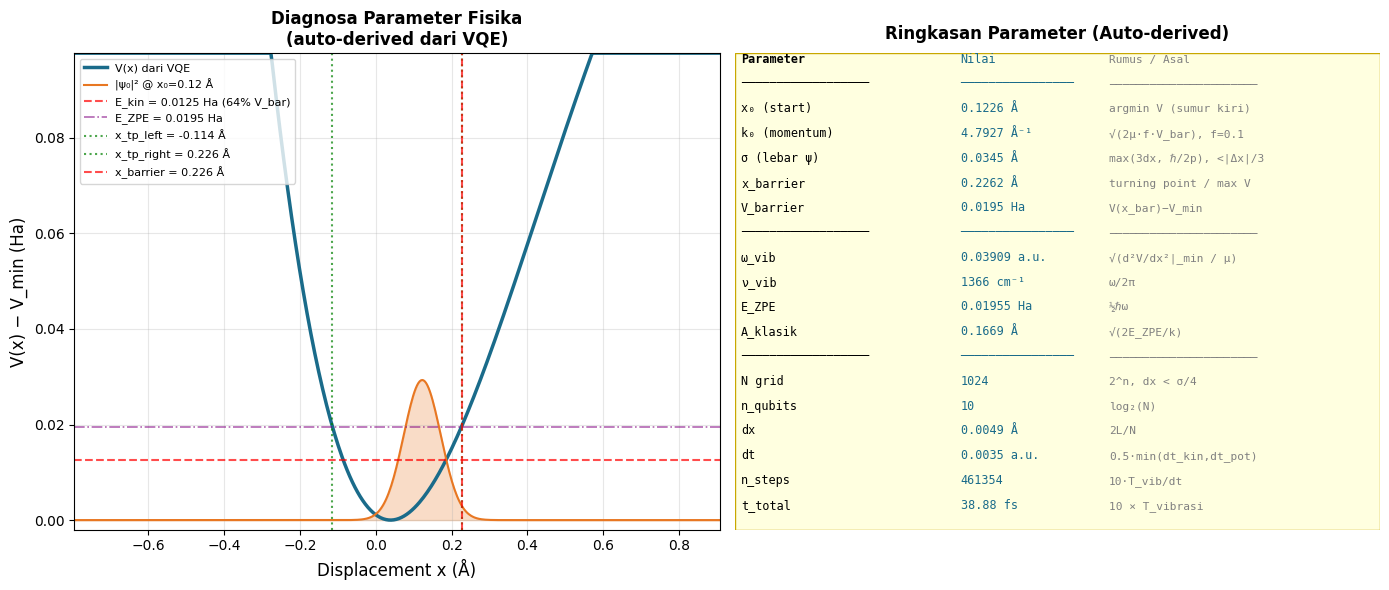

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Plot kiri: Potensial + semua parameter ────────────────────────────────────
ax1 = axes[0]

# ── Tentukan range fokus ketat di sekitar region fisika ──────────
x_center = (x_tp_left_zpe + x_tp_right_zpe) / 2
x_width  = abs(x_tp_right_zpe - x_tp_left_zpe)
margin   = x_width * 1.5          # buffer 150% kiri-kanan

x_lo = x_center - x_width - margin
x_hi = x_center + x_width + margin

x_plot   = np.linspace(x_lo, x_hi, 500)
V_plot   = V_vqe(x_plot) - V_min

# ── Clip V supaya dinding curam tidak mendominasi sumbu y ─────────
y_max    = V_barrier * 5          # tampilkan sampai 5× barrier
V_clipped = np.clip(V_plot, None, y_max)

ax1.plot(x_plot, V_clipped, color="#1A6B8A", lw=2.5, label="V(x) dari VQE")

# Wavepacket awal
psi0_plot  = np.exp(-(x_plot - x0)**2 / (4*sigma**2))
psi0_scaled = psi0_plot / psi0_plot.max() * y_max * 0.3
ax1.fill_between(x_plot, psi0_scaled, alpha=0.25, color="#E87722")
ax1.plot(x_plot, psi0_scaled, color="#E87722", lw=1.5,
         label=f"|ψ₀|² @ x₀={x0:.2f} Å")

# Garis referensi
ax1.axhline(E_kin,  color='red',    ls='--', lw=1.5, alpha=0.7,
            label=f"E_kin = {E_kin:.4f} Ha ({E_kin/V_barrier*100:.0f}% V_bar)")
ax1.axhline(E_ZPE,  color='purple', ls='-.', lw=1.2, alpha=0.6,
            label=f"E_ZPE = {E_ZPE:.4f} Ha")
ax1.axvline(x_tp_left_zpe,  color='green', ls=':', lw=1.5, alpha=0.7,
            label=f"x_tp_left = {x_tp_left_zpe:.3f} Å")
ax1.axvline(x_tp_right_zpe, color='green', ls=':', lw=1.5, alpha=0.7,
            label=f"x_tp_right = {x_tp_right_zpe:.3f} Å")
ax1.axvline(x_barrier, color='red', ls='--', lw=1.5, alpha=0.7,
            label=f"x_barrier = {x_barrier:.3f} Å")

# ── Set axis range ketat ──────────────────────────────────────────
ax1.set_xlim(x_lo, x_hi)
ax1.set_ylim(-0.002, y_max)

ax1.set_xlabel("Displacement x (Å)", fontsize=12)
ax1.set_ylabel("V(x) − V_min (Ha)", fontsize=12)
ax1.set_title("Diagnosa Parameter Fisika\n(auto-derived dari VQE)",
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(alpha=0.3)

# ── Plot kanan: Tabel ringkasan ───────────────────────────────────────────────
ax2 = axes[1]
ax2.axis('off')

tabel_data = [
    ["Parameter",           "Nilai",                    "Rumus / Asal"],
    ["─"*18,                "─"*16,                     "─"*22],
    ["x₀ (start)",          f"{x0:.4f} Å",              "argmin V (sumur kiri)"],
    ["k₀ (momentum)",       f"{k0:.4f} Å⁻¹",            "√(2μ·f·V_bar), f=0.1"],
    ["σ (lebar ψ)",         f"{sigma:.4f} Å",            "max(3dx, ℏ/2p), <|Δx|/3"],
    ["x_barrier",           f"{x_barrier:.4f} Å",        "turning point / max V"],
    ["V_barrier",           f"{V_barrier:.4f} Ha",       "V(x_bar)−V_min"],
    ["─"*18,                "─"*16,                     "─"*22],
    ["ω_vib",               f"{omega:.5f} a.u.",         "√(d²V/dx²|_min / μ)"],
    ["ν_vib",               f"{nu_cm1:.0f} cm⁻¹",        "ω/2π"],
    ["E_ZPE",               f"{E_ZPE:.5f} Ha",           "½ℏω"],
    ["A_klasik",            f"{A_classical:.4f} Å",      "√(2E_ZPE/k)"],
    ["─"*18,                "─"*16,                     "─"*22],
    ["N grid",              f"{N}",                      "2^n, dx < σ/4"],
    ["n_qubits",            f"{n_qubits}",               "log₂(N)"],
    ["dx",                  f"{dx:.4f} Å",               "2L/N"],
    ["dt",                  f"{dt_au:.4f} a.u.",          "0.5·min(dt_kin,dt_pot)"],
    ["n_steps",             f"{n_steps}",                 "10·T_vib/dt"],
    ["t_total",             f"{t_max_fs:.2f} fs",         "10 × T_vibrasi"],
]

for i, row in enumerate(tabel_data):
    y = 0.98 - i * 0.052
    ax2.text(0.01, y, row[0], transform=ax2.transAxes, fontsize=8.5,
             fontfamily='monospace',
             fontweight='bold' if i in [0, 1, 7, 12] else 'normal')
    ax2.text(0.35, y, row[1], transform=ax2.transAxes, fontsize=8.5,
             fontfamily='monospace', color='#1A6B8A')
    ax2.text(0.58, y, row[2], transform=ax2.transAxes, fontsize=8,
             fontfamily='monospace', color='gray')

ax2.set_title("Ringkasan Parameter (Auto-derived)",
              fontsize=12, fontweight='bold', pad=10)
ax2.add_patch(plt.Rectangle((0,0), 1, 1, fill=True, 
              facecolor='lightyellow', edgecolor='#C8A800',
              transform=ax2.transAxes, zorder=0))

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/auto_parameter_derivation.png",
#            dpi=150, bbox_inches='tight')
plt.show()

#print("\n✓ Plot diagnosa disimpan: auto_parameter_derivation.png")
#print("\nSalin nilai PARAMETER FINAL di atas ke h2_tunneling_trotter.py")